In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
class K_Kernel_Perceptron:

    def __init__(self, K, data, labels, kernel):
        """
        Input:
        K:      scalar, number of classes
        data:   (m, n) np array, m data points
        labels: (m, ) np array, labels of K classes
        kernel: function mapping from R^n x R^n to R
        """
        self.K = K
        self.X = data
        self.m, self.n = data.shape
        self.labels = labels
        self.kernel_func = kernel
        self.K_matrix = kernel(data, data) # (m, m)
        self.classes = np.unique(labels)
        self.y = np.array([np.where(labels == a, 1, -1) for a in self.classes]) # (K, m)
        

    def train(self, N_epochs):
        """
        Train multiple epochs
        """
        self.alpha = np.zeros((self.K, self.m)) # (K, m)
        for _ in range(N_epochs):
            for i in range(self.m):
                predicted_values = np.dot(self.alpha, self.K_matrix[i])
                self.alpha[:, i] += np.where(predicted_values * self.y[:, i] > 0, 0, 1) * self.y[:, i]

        predicts = (self.alpha @ self.K_matrix).T # (m, K)
        predicted_classes = self.classes[np.argmax(predicts, axis=1)]
        mistakes = np.sum(predicted_classes != self.labels) / self.m
        return predicted_classes, mistakes
        

    def predict(self, test_data, test_labels):
        test_kernel_matrix = self.kernel_func(self.X, test_data) # (m, test_n)
        predicts = (self.alpha @ test_kernel_matrix).T # (test_n, K)
        predicted_classes = self.classes[np.argmax(predicts, axis=1)]
        mistakes = np.sum(predicted_classes != test_labels) / len(test_labels)
        return predicted_classes, mistakes

In [4]:
def load_data(file_name):
    data = np.loadtxt(file_name)
    y = data[:,0]
    X = data[:, 1:]
    return X, y

In [5]:
def polynomial_kernel(d):
    def kernel(p, q):
        K_matrix = np.power(p @ q.T, d)
        return K_matrix
    return kernel

def gaussian_kernel(c):
    def kernel(p, q):
        p_sq = np.sum(p ** 2, axis=1).reshape(-1, 1)
        q_sq = np.sum(q ** 2, axis=1).reshape(1, -1)
        sq_dist = p_sq + q_sq - 2 * np.dot(p, q.T)
        K_matrix = np.exp(-c * sq_dist)
        return K_matrix
    return kernel

In [6]:
simple_train_data_file = 'dtrain123.dat'
simple_train_X, simple_train_y = load_data(simple_train_data_file)
simple_test_data_file = 'dtest123.dat'
simple_test_X, simple_test_y = load_data(simple_test_data_file)

In [7]:
simple_model = K_Kernel_Perceptron(3, simple_train_X, simple_train_y, polynomial_kernel(d = 1))

In [8]:
_, simple_train_error = simple_model.train(N_epochs = 2)

In [9]:
simple_train_error

0.015197568389057751

In [10]:
simple_predicted_class, simple_error = simple_model.predict(simple_test_X, simple_test_y)

In [11]:
simple_error

0.05263157894736842

In [12]:
full_data_file = 'zipcombo.dat'
full_X, full_y = load_data(full_data_file)

In [13]:
def data_partition(X, y, train_ratio):
    m = X.shape[0]
    permutation = np.random.permutation(m)
    train_size = int(m * train_ratio)
    train_indices = permutation[:train_size]
    test_indices = permutation[train_size:]
    X_train = X[train_indices]
    y_train = y[train_indices]
    X_test = X[test_indices]
    y_test = y[test_indices]
    return X_train, y_train, X_test, y_test

In [14]:
np.random.seed(100)

# Q2

In [ ]:
# perform cross-validation on epochs selection
train_ratio = 0.8
train_errors = np.zeros((10, 30))
test_errors = np.zeros((10, 30))
epochs = list(range(1, 31))
for _ in range(10):
    X_train, y_train, X_test, y_test = data_partition(full_X, full_y, train_ratio)
    for epoch in epochs:
        model = K_Kernel_Perceptron(10, X_train, y_train, polynomial_kernel(d = 2))
        train_pred, train_error = model.train(N_epochs = epoch)
        train_errors[_, epoch - 1] = train_error
        prediction, test_error = model.predict(X_test, y_test)
        test_errors[_, epoch - 1] = test_error
train_errors_mean = np.mean(train_errors, axis=0)
test_errors_mean = np.mean(test_errors, axis=0)

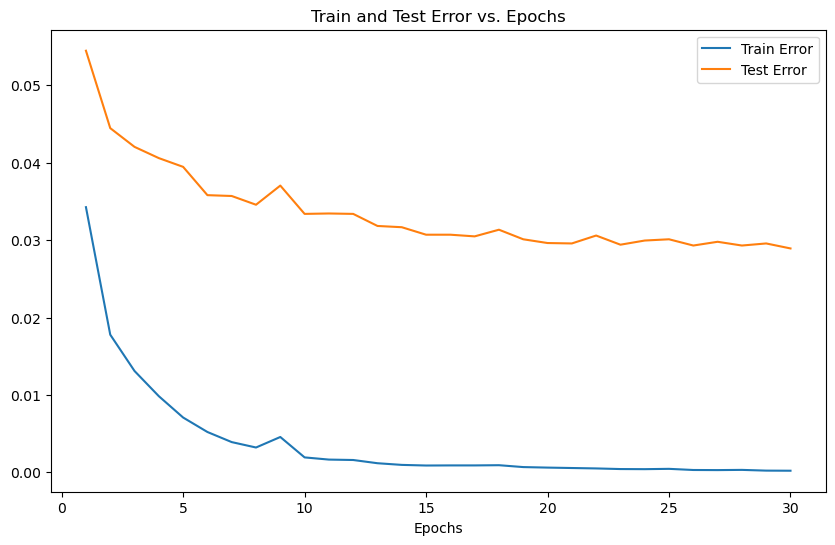

In [164]:
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_errors_mean, label='Train Error')
plt.plot(epochs, test_errors_mean, label='Test Error')
plt.xlabel('Epochs')
plt.legend()
plt.title('Train and Test Error vs. Epochs')
plt.show()

# Q3

In [303]:
num_of_run = 20
max_order_poly = 7
train_errors = np.zeros((num_of_run, max_order_poly))
test_errors = np.zeros((num_of_run, max_order_poly))
for _ in range(num_of_run):
    train_X, train_y, test_X, test_y = data_partition(full_X, full_y, 0.8)
    for i, d in enumerate(range(1, max_order_poly + 1)):
        this_model = K_Kernel_Perceptron(10, train_X, train_y, polynomial_kernel(d))
        train_pred, train_errors[_, i] = this_model.train(15)
        test_pred, test_errors[_, i] = this_model.predict(test_X, test_y)

In [15]:
import pandas as pd

In [304]:
train_error_mean = np.mean(train_errors, axis=0)
train_error_std = np.std(train_errors, axis=0)
test_error_mean = np.mean(test_errors, axis=0)
test_error_std = np.std(test_errors, axis=0)
ds = list(range(1, max_order_poly + 1))
train_summary = []
test_summary = []
for i in range(max_order_poly):
    train_summary.append(f'{train_error_mean[i]:g} \u00B1 {train_error_std[i]:g}')
    test_summary.append(f'{test_error_mean[i]:g} \u00B1 {test_error_std[i]:g}')
summary_df = pd.DataFrame({'d' : ds, 'Training' : train_summary, 'Testing' : test_summary})
print(summary_df.to_latex(index=False))

\begin{tabular}{rll}
\toprule
d & Training & Testing \\
\midrule
1 & 0.0610514 ± 0.00899232 & 0.0894086 ± 0.0085467 \\
2 & 0.00118984 ± 0.000991866 & 0.0316667 ± 0.00439711 \\
3 & 0.000242001 ± 0.000109223 & 0.0279839 ± 0.00325469 \\
4 & 0.000147889 ± 8.39607e-05 & 0.0269892 ± 0.00370773 \\
5 & 0.000194945 ± 0.000187621 & 0.0277957 ± 0.00361497 \\
6 & 0.000188223 ± 0.000177345 & 0.0273925 ± 0.00338101 \\
7 & 0.000215112 ± 0.000423874 & 0.0284946 ± 0.00348012 \\
\bottomrule
\end{tabular}



Text(0.5, 1.0, 'Train and Test Error vs. Order of Polynomial')

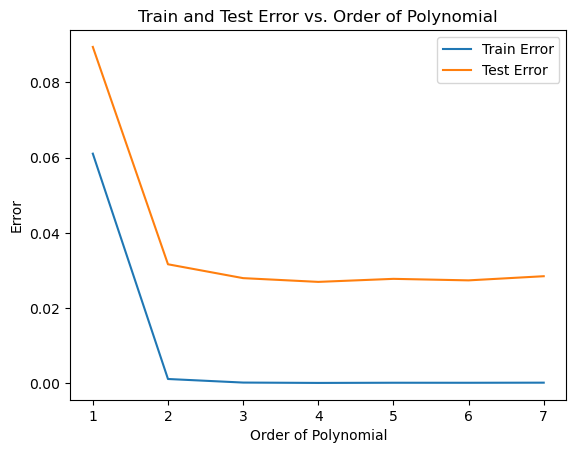

In [305]:
plt.plot(ds, train_error_mean, label='Train Error')
plt.plot(ds, test_error_mean, label='Test Error')
plt.xlabel('Order of Polynomial')
plt.ylabel('Error')
plt.legend()
plt.title('Train and Test Error vs. Order of Polynomial')

# Q4 & Q5

In [16]:
def split_data_k_fold(X, y, k):
    m = X.shape[0]
    fold_size = m // k
    permutation = np.random.permutation(m)
    X = X[permutation]
    y = y[permutation]
    X_folds = np.array([X[i * fold_size : (i + 1) * fold_size] for i in range(k)])
    y_folds = np.array([y[i * fold_size : (i + 1) * fold_size] for i in range(k)])
    return X_folds, y_folds

In [ ]:
optimal_d_training_errors = np.zeros(num_of_run)
optimal_d_testing_errors = np.zeros(num_of_run)
optimal_d = np.zeros(num_of_run)
whole_confusion_matrix = np.zeros((num_of_run, 10, 10))
for _ in range(num_of_run):
    train_X, train_y, test_X, test_y = data_partition(full_X, full_y, 0.8)
    X_folds, y_folds = split_data_k_fold(train_X, train_y, 5)
    cv_errors = np.zeros((5, max_order_poly))
    iFold = 0
    for sub_test_X, sub_test_y in zip(X_folds, y_folds):
        sub_train_X = np.concatenate([thisX for thisX in X_folds if not np.array_equal(thisX, sub_test_X)])
        sub_train_y = np.concatenate([thisy for thisy in y_folds if not np.array_equal(thisy, sub_test_y)])
        for i, d in enumerate(range(1, max_order_poly + 1)):
            this_model = K_Kernel_Perceptron(10, sub_train_X, sub_train_y, polynomial_kernel(d))
            this_model.train(15)
            test_pred, cv_errors[iFold, i] = this_model.predict(sub_test_X, sub_test_y)
        iFold += 1
    cv_errors_min = np.argmin(np.mean(cv_errors, axis=0))
    this_optimal_d = cv_errors_min + 1
    optimal_d[_] = this_optimal_d
    this_optimal_model = K_Kernel_Perceptron(10, train_X, train_y, polynomial_kernel(this_optimal_d))
    train_pred, optimal_d_training_errors[_] = this_optimal_model.train(15)
    test_pred, optimal_d_testing_errors[_] = this_optimal_model.predict(test_X, test_y)
    true_labels_count = np.bincount(test_y.astype(int))
    for true_label, predicted_label in zip(test_y, test_pred):
        if true_label != predicted_label:
            whole_confusion_matrix[_, int(true_label), int(predicted_label)] += 1
    whole_confusion_matrix[_, :, :] /= true_labels_count.reshape(-1, 1)

In [195]:
optimal_d

array([4., 5., 4., 6., 5., 4., 5., 5., 7., 3., 3., 6., 5., 5., 4., 3., 5.,
       3., 4., 4.])

In [180]:
optimal_d_training_errors_mean = np.mean(optimal_d_training_errors)
optimal_d_training_errors_std = np.std(optimal_d_training_errors)
optimal_d_testing_errors_mean = np.mean(optimal_d_testing_errors)
optimal_d_testing_errors_std = np.std(optimal_d_testing_errors)
confusion_matrix_mean = np.mean(whole_confusion_matrix, axis=0)
confusion_matrix_std = np.std(whole_confusion_matrix, axis=0)
summary_df = pd.DataFrame({'Metric': ['Training', 'Testing'], 'Error': [f'{optimal_d_training_errors_mean:g} \u00B1 {optimal_d_training_errors_std:g}', f'{optimal_d_testing_errors_mean:g} \u00B1 {optimal_d_testing_errors_std:g}']})
print(summary_df.to_latex(index=False))

\begin{tabular}{ll}
\toprule
Metric & Error \\
\midrule
Training & 0.000786502 ± 0.00272538 \\
Testing & 0.029086 ± 0.00541091 \\
\bottomrule
\end{tabular}



In [192]:
confusion_matrix_summary = []
for i in range(10):
    confusion_matrix_summary.append([''.join(f'{confusion_matrix_mean[i, j]:.2%} \u00B1 {confusion_matrix_std[i, j]:.2%}') for j in range(10)])

In [193]:
confusion_matrix_summary_df = pd.DataFrame(confusion_matrix_summary)

In [194]:
print(confusion_matrix_summary_df.to_latex())

\begin{tabular}{lllllllllll}
\toprule
 & 0 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 9 \\
\midrule
0 & 0.00% ± 0.00% & 0.08% ± 0.17% & 0.19% ± 0.24% & 0.15% ± 0.22% & 0.07% ± 0.13% & 0.18% ± 0.24% & 0.23% ± 0.20% & 0.02% ± 0.07% & 0.05% ± 0.11% & 0.11% ± 0.18% \\
1 & 0.00% ± 0.00% & 0.00% ± 0.00% & 0.10% ± 0.21% & 0.04% ± 0.16% & 0.86% ± 2.88% & 0.00% ± 0.00% & 0.07% ± 0.19% & 0.18% ± 0.27% & 0.12% ± 0.22% & 0.02% ± 0.08% \\
2 & 0.33% ± 0.36% & 0.13% ± 0.28% & 0.00% ± 0.00% & 0.81% ± 0.66% & 0.46% ± 0.61% & 0.15% ± 0.32% & 0.17% ± 0.26% & 0.41% ± 0.42% & 0.29% ± 0.32% & 0.05% ± 0.23% \\
3 & 0.19% ± 0.29% & 0.13% ± 0.33% & 0.63% ± 0.55% & 0.00% ± 0.00% & 0.06% ± 0.19% & 1.97% ± 1.46% & 0.00% ± 0.00% & 0.26% ± 0.32% & 0.93% ± 0.63% & 0.19% ± 0.33% \\
4 & 0.03% ± 0.12% & 0.80% ± 0.59% & 0.74% ± 0.60% & 0.08% ± 0.19% & 0.00% ± 0.00% & 0.12% ± 0.29% & 0.39% ± 0.64% & 0.25% ± 0.33% & 0.06% ± 0.17% & 0.84% ± 0.87% \\
5 & 0.95% ± 0.74% & 0.07% ± 0.21% & 0.38% ± 0.46% & 1.35% ± 1.08% & 0.47% ± 0.60% & 

# Q6

In [32]:
misclassifications = np.array([], dtype=int)
num_of_run = 100
max_order_poly = 7
for _ in range(num_of_run):
    train_X, train_y, test_X, test_y = data_partition(full_X, full_y, 0.8)
    X_folds, y_folds = split_data_k_fold(train_X, train_y, 5)
    cv_errors = np.zeros((5, max_order_poly))
    iFold = 0
    for sub_test_X, sub_test_y in zip(X_folds, y_folds):
        sub_train_X = np.concatenate([thisX for thisX in X_folds if not np.array_equal(thisX, sub_test_X)])
        sub_train_y = np.concatenate([thisy for thisy in y_folds if not np.array_equal(thisy, sub_test_y)])
        for i, d in enumerate(range(1, max_order_poly + 1)):
            this_model = K_Kernel_Perceptron(10, sub_train_X, sub_train_y, polynomial_kernel(d))
            this_model.train(15)
            test_pred, cv_errors[iFold, i] = this_model.predict(sub_test_X, sub_test_y)
        iFold += 1
    cv_errors_min = np.argmin(np.mean(cv_errors, axis=0))
    this_optimal_d = cv_errors_min + 1
    this_optimal_model = K_Kernel_Perceptron(10, train_X, train_y, polynomial_kernel(this_optimal_d))
    train_pred, train_error = this_optimal_model.train(15)
    test_pred, test_error = this_optimal_model.predict(full_X, full_y)
    misclassifications = np.concatenate((misclassifications, np.argwhere(test_pred != full_y).flatten()))
            

In [33]:
hardest_idx = np.argsort(np.bincount(misclassifications))[::-1][:10]

In [34]:
hardest_idx

array([5296, 8261, 7524, 2377, 6356, 7413, 3227, 7630, 8835, 8337])

In [37]:
np.sort(np.bincount(misclassifications))[::-1][:10]

array([98, 52, 30, 30, 28, 28, 28, 28, 27, 26])

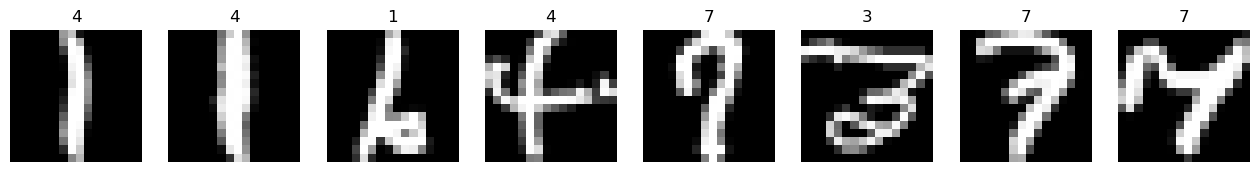

In [39]:
hardest_X = full_X[hardest_idx]
hardest_y = full_y[hardest_idx]
# plot the hardest digits
fig, ax = plt.subplots(1, 8, figsize=(16, 2))
for i in range(8):
    ax[i].imshow(hardest_X[i].reshape(16, 16), cmap='gray')
    ax[i].set_title(f'{hardest_y[i]:g}')
    ax[i].axis('off')


# Q7

In [17]:
powers = np.arange(-10, -1)

In [18]:
S = np.exp2(powers)

In [292]:
num_of_run = 20
size_of_S = len(S)
train_errors = np.zeros((num_of_run, size_of_S))
test_errors = np.zeros((num_of_run, size_of_S))
for _ in range(num_of_run):
    train_X, train_y, test_X, test_y = data_partition(full_X, full_y, 0.8)
    for i, c in enumerate(S):
        this_model = K_Kernel_Perceptron(10, train_X, train_y, gaussian_kernel(c))
        train_pred, train_errors[_, i] = this_model.train(15)
        test_pred, test_errors[_, i] = this_model.predict(test_X, test_y)

In [297]:
train_error_mean = np.mean(train_errors, axis=0)
train_error_std = np.std(train_errors, axis=0)
test_error_mean = np.mean(test_errors, axis=0)
test_error_std = np.std(test_errors, axis=0)
train_summary = []
test_summary = []
cs = []
for i in range(len(S)):
    cs.append(f'2^{powers[i]:d}')
    train_summary.append(f'{train_error_mean[i]:g} \u00B1 {train_error_std[i]:g}')
    test_summary.append(f'{test_error_mean[i]:g} \u00B1 {test_error_std[i]:g}')
summary_df = pd.DataFrame({'c' : cs, 'Training' : train_summary, 'Testing' : test_summary})
print(summary_df.to_latex(index=False))

\begin{tabular}{lll}
\toprule
c & Training & Testing \\
\midrule
2^-10 & 0.0334364 ± 0.0140637 & 0.0615323 ± 0.0138366 \\
2^-9 & 0.00754235 ± 0.0039516 & 0.0401613 ± 0.00698532 \\
2^-8 & 0.000645335 ± 0.000445091 & 0.0312366 ± 0.00494478 \\
2^-7 & 0.000349556 ± 0.000586648 & 0.0273656 ± 0.00388029 \\
2^-6 & 0.000275612 ± 0.000507473 & 0.0262634 ± 0.00462889 \\
2^-5 & 0.000168056 ± 0.000331714 & 0.0311559 ± 0.00454126 \\
2^-4 & 6.72224e-06 ± 2.93016e-05 & 0.0439247 ± 0.00481205 \\
2^-3 & 0 ± 0 & 0.0574462 ± 0.00508704 \\
2^-2 & 0 ± 0 & 0.0655645 ± 0.00419725 \\
\bottomrule
\end{tabular}



Text(0.5, 1.0, 'Train and Test Error vs. $\\log_2$c')

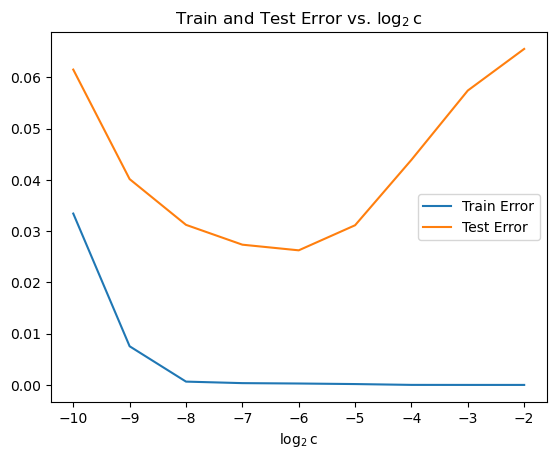

In [302]:
plt.plot(powers, train_error_mean, label='Train Error')
plt.plot(powers, test_error_mean, label='Test Error')
plt.xlabel(r'$\log_2$c')
plt.legend()
plt.title(r'Train and Test Error vs. $\log_2$c')

In [19]:
optimal_c_training_errors = np.zeros(num_of_run)
optimal_c_testing_errors = np.zeros(num_of_run)
optimal_c = np.zeros(num_of_run)
whole_confusion_matrix = np.zeros((num_of_run, 10, 10))
for _ in range(num_of_run):
    train_X, train_y, test_X, test_y = data_partition(full_X, full_y, 0.8)
    X_folds, y_folds = split_data_k_fold(train_X, train_y, 5)
    cv_errors = np.zeros((5, len(S)))
    iFold = 0
    for sub_test_X, sub_test_y in zip(X_folds, y_folds):
        sub_train_X = np.concatenate([thisX for thisX in X_folds if not np.array_equal(thisX, sub_test_X)])
        sub_train_y = np.concatenate([thisy for thisy in y_folds if not np.array_equal(thisy, sub_test_y)])
        for i, c in enumerate(S):
            this_model = K_Kernel_Perceptron(10, sub_train_X, sub_train_y, gaussian_kernel(c))
            this_model.train(15)
            test_pred, cv_errors[iFold, i] = this_model.predict(sub_test_X, sub_test_y)
        iFold += 1
    cv_errors_min = np.argmin(np.mean(cv_errors, axis=0))
    this_optimal_c = S[cv_errors_min]
    optimal_c[_] = this_optimal_c
    this_optimal_model = K_Kernel_Perceptron(10, train_X, train_y, gaussian_kernel(this_optimal_c))
    train_pred, optimal_c_training_errors[_] = this_optimal_model.train(15)
    test_pred, optimal_c_testing_errors[_] = this_optimal_model.predict(test_X, test_y)
    true_labels_count = np.bincount(test_y.astype(int))
    for true_label, predicted_label in zip(test_y, test_pred):
        if true_label != predicted_label:
            whole_confusion_matrix[_, int(true_label), int(predicted_label)] += 1
    whole_confusion_matrix[_, :, :] /= true_labels_count.reshape(-1, 1)

In [20]:
optimal_c

array([0.015625 , 0.015625 , 0.015625 , 0.015625 , 0.0078125, 0.015625 ,
       0.0078125, 0.015625 , 0.015625 , 0.015625 , 0.015625 , 0.015625 ,
       0.015625 , 0.015625 , 0.015625 , 0.015625 , 0.0078125, 0.015625 ,
       0.0078125, 0.015625 ])

In [21]:
np.log2(optimal_c)

array([-6., -6., -6., -6., -7., -6., -7., -6., -6., -6., -6., -6., -6.,
       -6., -6., -6., -7., -6., -7., -6.])

In [22]:
optimal_c_training_errors_mean = np.mean(optimal_c_training_errors)
optimal_c_training_errors_std = np.std(optimal_c_training_errors)
optimal_c_testing_errors_mean = np.mean(optimal_c_testing_errors)
optimal_c_testing_errors_std = np.std(optimal_c_testing_errors)
confusion_matrix_mean = np.mean(whole_confusion_matrix, axis=0)
confusion_matrix_std = np.std(whole_confusion_matrix, axis=0)
summary_df = pd.DataFrame({'Metric': ['Training', 'Testing'], 'Error': [f'{optimal_c_training_errors_mean:g} \u00B1 {optimal_c_training_errors_std:g}', f'{optimal_c_testing_errors_mean:g} \u00B1 {optimal_c_testing_errors_std:g}']})
print(summary_df.to_latex(index=False))

\begin{tabular}{ll}
\toprule
Metric & Error \\
\midrule
Training & 0.0001815 ± 0.0001223 \\
Testing & 0.0255376 ± 0.00365631 \\
\bottomrule
\end{tabular}



# Q8

In [40]:
class Binary_Kernel_Perceptron:

    def __init__(self, data, labels, kernel):
        """
        Input:
        K:      scalar, number of classes
        data:   (m, n) np array, m data points
        labels: (m, ) np array, 1 or -1 labels
        kernel: function mapping from R^n x R^n to R
        """
        self.X = data
        self.m, self.n = data.shape
        self.y = labels
        self.kernel_func = kernel
        self.K_matrix = kernel(data, data) # (m, m)
        

    def train(self, N_epochs):
        """
        Train multiple epochs
        """
        self.alpha = np.zeros(self.m) # (m, )
        for _ in range(N_epochs):
            for i in range(self.m):
                predicted_values = np.dot(self.alpha, self.K_matrix[i])
                self.alpha[i] += (0 if predicted_values * self.y[i] > 0 else self.y[i])

        predicts = np.where((self.alpha @ self.K_matrix).flatten() > 0, 1, -1) # (m,)
        mistakes = np.sum(predicts != self.y) / self.m
        return predicts, mistakes
        

    def predict(self, test_data, test_labels):
        test_kernel_matrix = self.kernel_func(self.X, test_data) # (m, test_n)
        predicts = np.where((self.alpha @ test_kernel_matrix).flatten() > 0, 1, -1) # (test_n,)
        mistakes = np.sum(predicts != test_labels) / len(test_labels)
        return predicts, mistakes

In [41]:
from itertools import combinations

class OvO_Kernel_Perceptron:

    def __init__(self, data, labels, kernel):
        """
        Input:
        K:      scalar, number of classes
        data:   (m, n) np array, m data points
        labels: (m, ) np array, labels of K classes
        kernel: function mapping from R^n x R^n to R
        """
        self.X = data
        self.labels = labels
        self.classes = np.unique(labels)
        self.K = len(self.classes)
        self.pairwise_classes = list(combinations(self.classes, 2))
        self.pairwise_models = []
        self.pairwise_indices = []
        for (a, b) in self.pairwise_classes:
            relevant_indices = np.logical_or(labels == a, labels == b)
            self.pairwise_indices.append(relevant_indices)
            X_ab = data[relevant_indices]
            y_ab = np.where(labels[relevant_indices] == a, 1, -1)
            self.pairwise_models.append(Binary_Kernel_Perceptron(X_ab, y_ab, kernel))

    def train(self, N_epochs):
        """
        Train multiple epochs
        """
        voting_matrix = np.zeros((self.X.shape[0], self.K))
        i = 0
        for (a, b), model in zip(self.pairwise_classes, self.pairwise_models):
            this_pred, _ = model.train(N_epochs)
            voting_matrix[self.pairwise_indices[i], int(a)] += np.where(this_pred == 1, 1, 0)
            voting_matrix[self.pairwise_indices[i], int(b)] += np.where(this_pred == -1, 1, 0)
            i += 1
        predicts = self.classes[np.argmax(voting_matrix, axis=1)]
        mistakes = np.sum(predicts != self.labels) / len(self.labels)
        return predicts, mistakes
    
    def predict(self, test_data, test_labels):
        voting_matrix = np.zeros((test_data.shape[0], self.K))
        for (a, b), model in zip(self.pairwise_classes, self.pairwise_models):
            this_pred, _ = model.predict(test_data, test_labels)
            voting_matrix[:, int(a)] += np.where(this_pred == 1, 1, 0)
            voting_matrix[:, int(b)] += np.where(this_pred == -1, 1, 0)
        predicts = self.classes[np.argmax(voting_matrix, axis=1)]
        mistakes = np.sum(predicts != test_labels) / len(test_labels)
        return predicts, mistakes

In [44]:
# do cross-validation on epochs selection for binary kernel perceptron for data pair (0, 1)
train_ratio = 0.8
train_errors = np.zeros((10, 20))
test_errors = np.zeros((10, 20))
epochs = list(range(1, 21))
pairwise_classes = (0, 1)
pairwise_indices = np.logical_or(full_y == pairwise_classes[0], full_y == pairwise_classes[1])
pairwise_X = full_X[pairwise_indices]
pairwise_y = np.where(full_y[pairwise_indices] == pairwise_classes[0], 1, -1)
for _ in range(10):
    pairwise_X_train, pairwise_y_train, pairwise_X_test, pairwise_y_test = data_partition(pairwise_X, pairwise_y, train_ratio)
    for epoch in epochs:
        model = Binary_Kernel_Perceptron(pairwise_X_train, pairwise_y_train, polynomial_kernel(d=3))
        train_pred, train_error = model.train(N_epochs = epoch)
        train_errors[_, epoch - 1] = train_error
        prediction, test_error = model.predict(pairwise_X_test, pairwise_y_test)
        test_errors[_, epoch - 1] = test_error
train_errors_mean = np.mean(train_errors, axis=0)
test_errors_mean = np.mean(test_errors, axis=0)

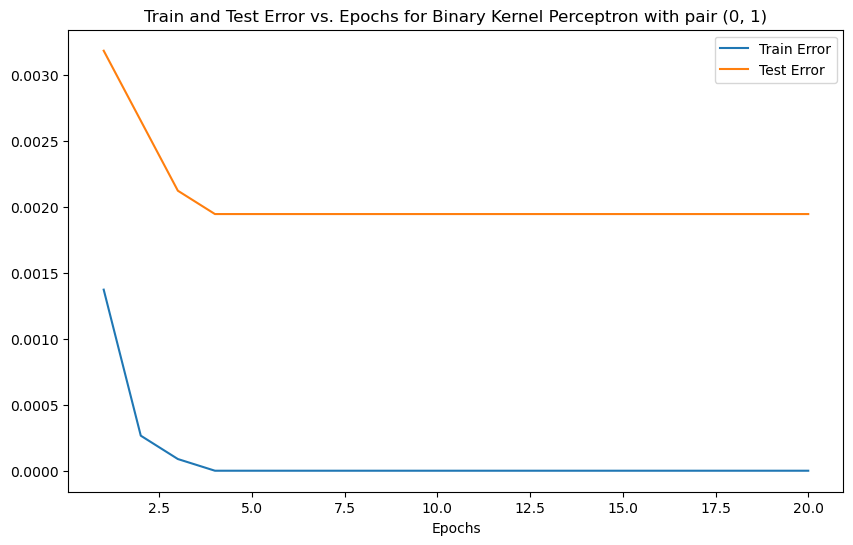

In [45]:
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_errors_mean, label='Train Error')
plt.plot(epochs, test_errors_mean, label='Test Error')
plt.xlabel('Epochs')
plt.legend()
plt.title('Train and Test Error vs. Epochs for Binary Kernel Perceptron with pair (0, 1)')
plt.show()

In [46]:
train_errors_mean

array([1.37350465e-03, 2.65839610e-04, 8.86132034e-05, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [47]:
test_errors_mean

array([0.00318584, 0.00265487, 0.00212389, 0.0019469 , 0.0019469 ,
       0.0019469 , 0.0019469 , 0.0019469 , 0.0019469 , 0.0019469 ,
       0.0019469 , 0.0019469 , 0.0019469 , 0.0019469 , 0.0019469 ,
       0.0019469 , 0.0019469 , 0.0019469 , 0.0019469 , 0.0019469 ])

In [ ]:
# do cross-validation on epochs selection for OvO kernel perceptron
train_ratio = 0.8
train_errors = np.zeros((10, 20))
test_errors = np.zeros((10, 20))
epochs = list(range(1, 21))
for _ in range(10):
    X_train, y_train, X_test, y_test = data_partition(full_X, full_y, train_ratio)
    model = OvO_Kernel_Perceptron(X_train, y_train, polynomial_kernel(d=3))
    for epoch in epochs:
        train_pred, train_error = model.train(N_epochs = epoch)
        train_errors[_, epoch - 1] = train_error
        prediction, test_error = model.predict(X_test, y_test)
        test_errors[_, epoch - 1] = test_error
train_errors_mean = np.mean(train_errors, axis=0)
test_errors_mean = np.mean(test_errors, axis=0)

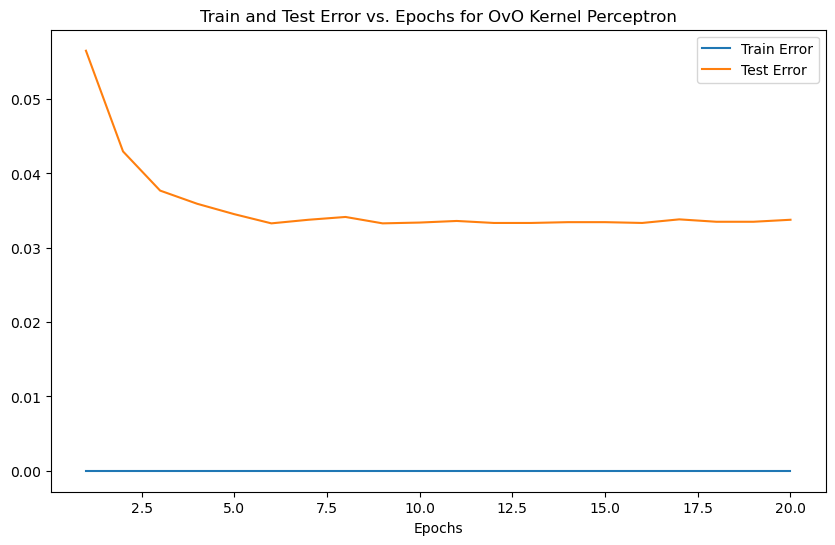

In [49]:
# plot the train and test error vs. epochs for OvO kernel perceptron
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_errors_mean, label='Train Error')
plt.plot(epochs, test_errors_mean, label='Test Error')
plt.xlabel('Epochs')
plt.legend()
plt.title('Train and Test Error vs. Epochs for OvO Kernel Perceptron')
plt.show()

In [52]:
train_errors_mean

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])

In [53]:
test_errors_mean

array([0.05650538, 0.04295699, 0.03768817, 0.03591398, 0.03451613,
       0.03327957, 0.03376344, 0.03413978, 0.03327957, 0.0333871 ,
       0.03360215, 0.03333333, 0.03333333, 0.03344086, 0.03344086,
       0.03333333, 0.0338172 , 0.03349462, 0.03349462, 0.03376344])

In [ ]:
num_of_run = 20
max_order_poly = 7
train_errors = np.zeros((num_of_run, max_order_poly))
test_errors = np.zeros((num_of_run, max_order_poly))
for _ in range(num_of_run):
    train_X, train_y, test_X, test_y = data_partition(full_X, full_y, 0.8)
    for i, d in enumerate(range(1, max_order_poly + 1)):
        this_model = OvO_Kernel_Perceptron(train_X, train_y, polynomial_kernel(d))
        train_pred, train_errors[_, i] = this_model.train(15)
        test_pred, test_errors[_, i] = this_model.predict(test_X, test_y)

In [40]:
train_error_mean = np.mean(train_errors, axis=0)
train_error_std = np.std(train_errors, axis=0)
test_error_mean = np.mean(test_errors, axis=0)
test_error_std = np.std(test_errors, axis=0)
ds = list(range(1, max_order_poly + 1))
train_summary = []
test_summary = []
for i in range(max_order_poly):
    train_summary.append(f'{train_error_mean[i]:g} \u00B1 {train_error_std[i]:g}')
    test_summary.append(f'{test_error_mean[i]:g} \u00B1 {test_error_std[i]:g}')
summary_df = pd.DataFrame({'d' : ds, 'Training' : train_summary, 'Testing' : test_summary})
print(summary_df.to_latex(index=False))

\begin{tabular}{rll}
\toprule
d & Training & Testing \\
\midrule
1 & 0 ± 0 & 0.0637903 ± 0.00865954 \\
2 & 0 ± 0 & 0.0340591 ± 0.00399906 \\
3 & 0 ± 0 & 0.0312366 ± 0.00362216 \\
4 & 0 ± 0 & 0.031586 ± 0.00275652 \\
5 & 0 ± 0 & 0.0329839 ± 0.00338443 \\
6 & 0 ± 0 & 0.0340054 ± 0.00366963 \\
7 & 0 ± 0 & 0.0343817 ± 0.00347378 \\
\bottomrule
\end{tabular}



Text(0.5, 1.0, 'OvO Train and Test Error vs. Order of Polynomial')

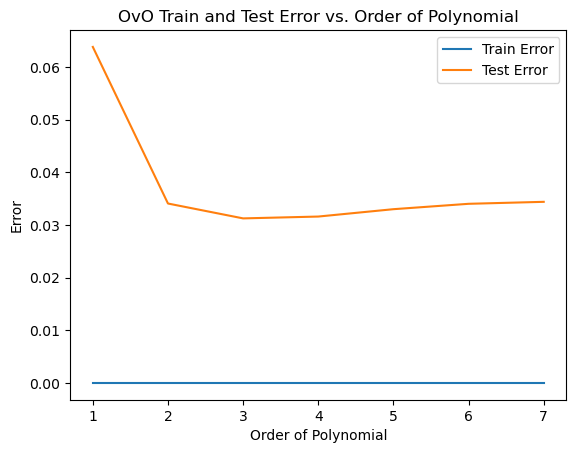

In [42]:
plt.plot(ds, train_error_mean, label='Train Error')
plt.plot(ds, test_error_mean, label='Test Error')
plt.xlabel('Order of Polynomial')
plt.ylabel('Error')
plt.legend()
plt.title('OvO Train and Test Error vs. Order of Polynomial')

In [43]:
optimal_d_training_errors = np.zeros(num_of_run)
optimal_d_testing_errors = np.zeros(num_of_run)
optimal_d = np.zeros(num_of_run)
whole_confusion_matrix = np.zeros((num_of_run, 10, 10))
for _ in range(num_of_run):
    train_X, train_y, test_X, test_y = data_partition(full_X, full_y, 0.8)
    X_folds, y_folds = split_data_k_fold(train_X, train_y, 5)
    cv_errors = np.zeros((5, max_order_poly))
    iFold = 0
    for sub_test_X, sub_test_y in zip(X_folds, y_folds):
        sub_train_X = np.concatenate([thisX for thisX in X_folds if not np.array_equal(thisX, sub_test_X)])
        sub_train_y = np.concatenate([thisy for thisy in y_folds if not np.array_equal(thisy, sub_test_y)])
        for i, d in enumerate(range(1, max_order_poly + 1)):
            this_model = OvO_Kernel_Perceptron(sub_train_X, sub_train_y, polynomial_kernel(d))
            this_model.train(15)
            test_pred, cv_errors[iFold, i] = this_model.predict(sub_test_X, sub_test_y)
        iFold += 1
    cv_errors_min = np.argmin(np.mean(cv_errors, axis=0))
    this_optimal_d = cv_errors_min + 1
    optimal_d[_] = this_optimal_d
    this_optimal_model = OvO_Kernel_Perceptron(train_X, train_y, polynomial_kernel(this_optimal_d))
    train_pred, optimal_d_training_errors[_] = this_optimal_model.train(15)
    test_pred, optimal_d_testing_errors[_] = this_optimal_model.predict(test_X, test_y)
    true_labels_count = np.bincount(test_y.astype(int))
    for true_label, predicted_label in zip(test_y, test_pred):
        if true_label != predicted_label:
            whole_confusion_matrix[_, int(true_label), int(predicted_label)] += 1
    whole_confusion_matrix[_, :, :] /= true_labels_count.reshape(-1, 1)

In [44]:
optimal_d

array([4., 4., 4., 6., 3., 4., 3., 3., 3., 4., 4., 5., 3., 3., 5., 2., 3.,
       6., 5., 3.])

In [45]:
optimal_d_training_errors_mean = np.mean(optimal_d_training_errors)
optimal_d_training_errors_std = np.std(optimal_d_training_errors)
optimal_d_testing_errors_mean = np.mean(optimal_d_testing_errors)
optimal_d_testing_errors_std = np.std(optimal_d_testing_errors)
confusion_matrix_mean = np.mean(whole_confusion_matrix, axis=0)
confusion_matrix_std = np.std(whole_confusion_matrix, axis=0)
summary_df = pd.DataFrame({'Metric': ['Training', 'Testing'], 'Error': [f'{optimal_d_training_errors_mean:g} \u00B1 {optimal_d_training_errors_std:g}', f'{optimal_d_testing_errors_mean:g} \u00B1 {optimal_d_testing_errors_std:g}']})
print(summary_df.to_latex(index=False))

\begin{tabular}{ll}
\toprule
Metric & Error \\
\midrule
Training & 0 ± 0 \\
Testing & 0.031586 ± 0.00385404 \\
\bottomrule
\end{tabular}

